In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# this dataset tracks daily commodity prices across different states and markets
df = pd.read_csv("/content/commodity_prices.csv")

In [ ]:
df

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,2,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,3,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,4,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,5,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...,...
751,752,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,753,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,754,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,755,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [ ]:
# removing those unnamed columns
df = df.drop(columns = ['Unnamed: 0'])

In [ ]:
df

,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...
751,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             756 non-null    object 
 1   oil_brent        756 non-null    float64
 2   oil_dubai        756 non-null    float64
 3   coffee_arabica   756 non-null    float64
 4   coffee_robustas  756 non-null    float64
 5   tea_columbo      756 non-null    float64
 6   tea_kolkata      756 non-null    float64
 7   tea_mombasa      756 non-null    float64
 8   sugar_eu         756 non-null    float64
 9   sugar_us         756 non-null    float64
 10  sugar_world      756 non-null    float64
dtypes: float64(10), object(1)
memory usage: 65.1+ KB


In [ ]:
# as convert date colm to DateTime dtype
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Created new features:
#  Month and Year from Date

df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year

#        for better trend analysis and ensured the data is clean

In [ ]:
# If you have a Date column
df['Year'] = pd.to_datetime(df['date']).dt.year


In [ ]:
df.head()

,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world,Month,Year
0,1960-01-01,1.63,1.63,0.9409,0.696864,0.930301,1.121401,1.0374,0.122356,0.116845,0.0666,1,1960
1,1960-02-01,1.63,1.63,0.9469,0.688707,0.930301,1.121401,1.0374,0.122356,0.119049,0.0679,2,1960
2,1960-03-01,1.63,1.63,0.9281,0.688707,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683,3,1960
3,1960-04-01,1.63,1.63,0.9303,0.684519,0.930301,1.121401,1.0374,0.122356,0.123459,0.0681,4,1960
4,1960-05-01,1.63,1.63,0.9200,0.690692,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683,5,1960


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             756 non-null    datetime64[ns]
 1   oil_brent        756 non-null    float64       
 2   oil_dubai        756 non-null    float64       
 3   coffee_arabica   756 non-null    float64       
 4   coffee_robustas  756 non-null    float64       
 5   tea_columbo      756 non-null    float64       
 6   tea_kolkata      756 non-null    float64       
 7   tea_mombasa      756 non-null    float64       
 8   sugar_eu         756 non-null    float64       
 9   sugar_us         756 non-null    float64       
 10  sugar_world      756 non-null    float64       
 11  Month            756 non-null    int32         
 12  Year             756 non-null    int32         
dtypes: datetime64[ns](1), float64(10), int32(2)
memory usage: 71.0 KB


In [ ]:
# data Cleaning

In [ ]:
df.isnull().sum()


,0
date,0
oil_brent,0
oil_dubai,0
coffee_arabica,0
coffee_robustas,0
tea_columbo,0
tea_kolkata,0
tea_mombasa,0
sugar_eu,0
sugar_us,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['date', 'oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world', 'Month', 'Year'],
      dtype='object')

In [ ]:
print(df.columns.tolist())


['date', 'oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas', 'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us', 'sugar_world', 'Month', 'Year']


In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['date', 'oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world', 'Month', 'Year'],
      dtype='object')

***By Grouping we can combine multiple rows into one summary per group — here, one per year**

In [ ]:
# as data has many rows per year,so wecalculate average oil price per year
df_yearly = df.groupby('Year')['oil_brent'].mean().reset_index()
print(df_yearly)

    Year  oil_brent
0   1960   1.630000
1   1961   1.570000
2   1962   1.520000
3   1963   1.500000
4   1964   1.450000
..   ...        ...
58  2018  71.071667
59  2019  64.031667
60  2020  42.300000
61  2021  70.443333
62  2022  99.824167

[63 rows x 2 columns]


****Doing the same for all Columns****

In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['date', 'oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world', 'Month', 'Year'],
      dtype='object')

In [ ]:
df_yearly = df.groupby('Year').mean(numeric_only=True).reset_index()
print(df_yearly.head())

   Year  oil_brent  oil_dubai  coffee_arabica  coffee_robustas  tea_columbo  \
0  1960       1.63       1.63        0.923517         0.695946     0.930301   
1  1961       1.57       1.57        0.895542         0.669436     0.892501   
2  1962       1.52       1.52        0.832592         0.682204     0.861001   
3  1963       1.50       1.50        0.805742         0.623507     0.814801   
4  1964       1.45       1.45        1.009758         0.787068     0.819001   

   tea_kolkata  tea_mombasa  sugar_eu  sugar_us  sugar_world  Month  
0     1.121401       1.0374  0.122356  0.125847     0.066208    6.5  
1     0.978601       0.9842  0.124341  0.125663     0.059450    6.5  
2     1.104601       0.9534  0.126325  0.128419     0.061683    6.5  
3     1.083601       0.9604  0.126766  0.165898     0.183233    6.5  
4     1.039501       0.9226  0.126582  0.138707     0.126325    6.5  


***Plotting all columns vs Time***

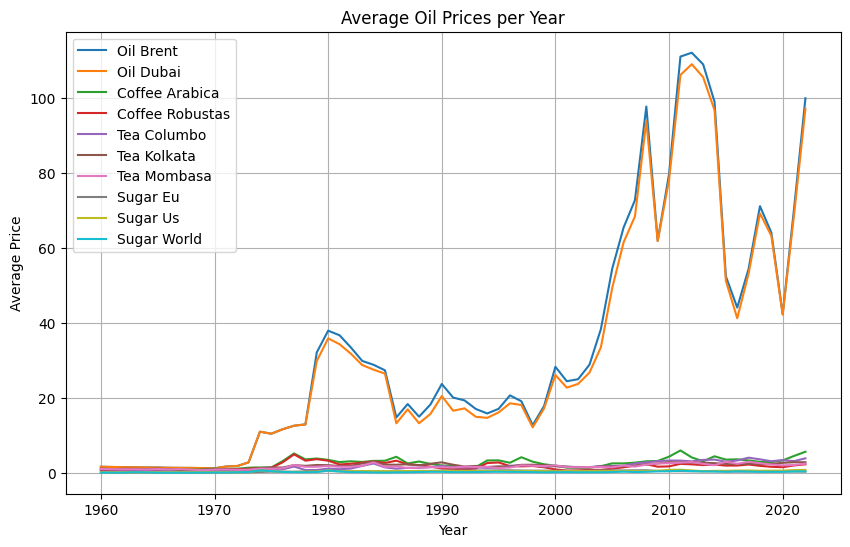

In [ ]:
import matplotlib.pyplot as plt

# First, group by Year and calculate the average
df_yearly = df.groupby('Year').mean(numeric_only=True)

# List of all oil columns
oil_columns = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas', 'tea_columbo',
 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us', 'sugar_world']

# Plot each oil column
plt.figure(figsize=(10, 6))
for col in oil_columns:
    plt.plot(df_yearly.index, df_yearly[col], label=col.replace('_', ' ').title())

plt.title('Average Oil Prices per Year')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.legend()
plt.grid(True)
plt.show()


When plotted on the same scale, commodities with small variations look like a straight line compared to those with bigger changes (like oil)

so plot it seperately as each graphs

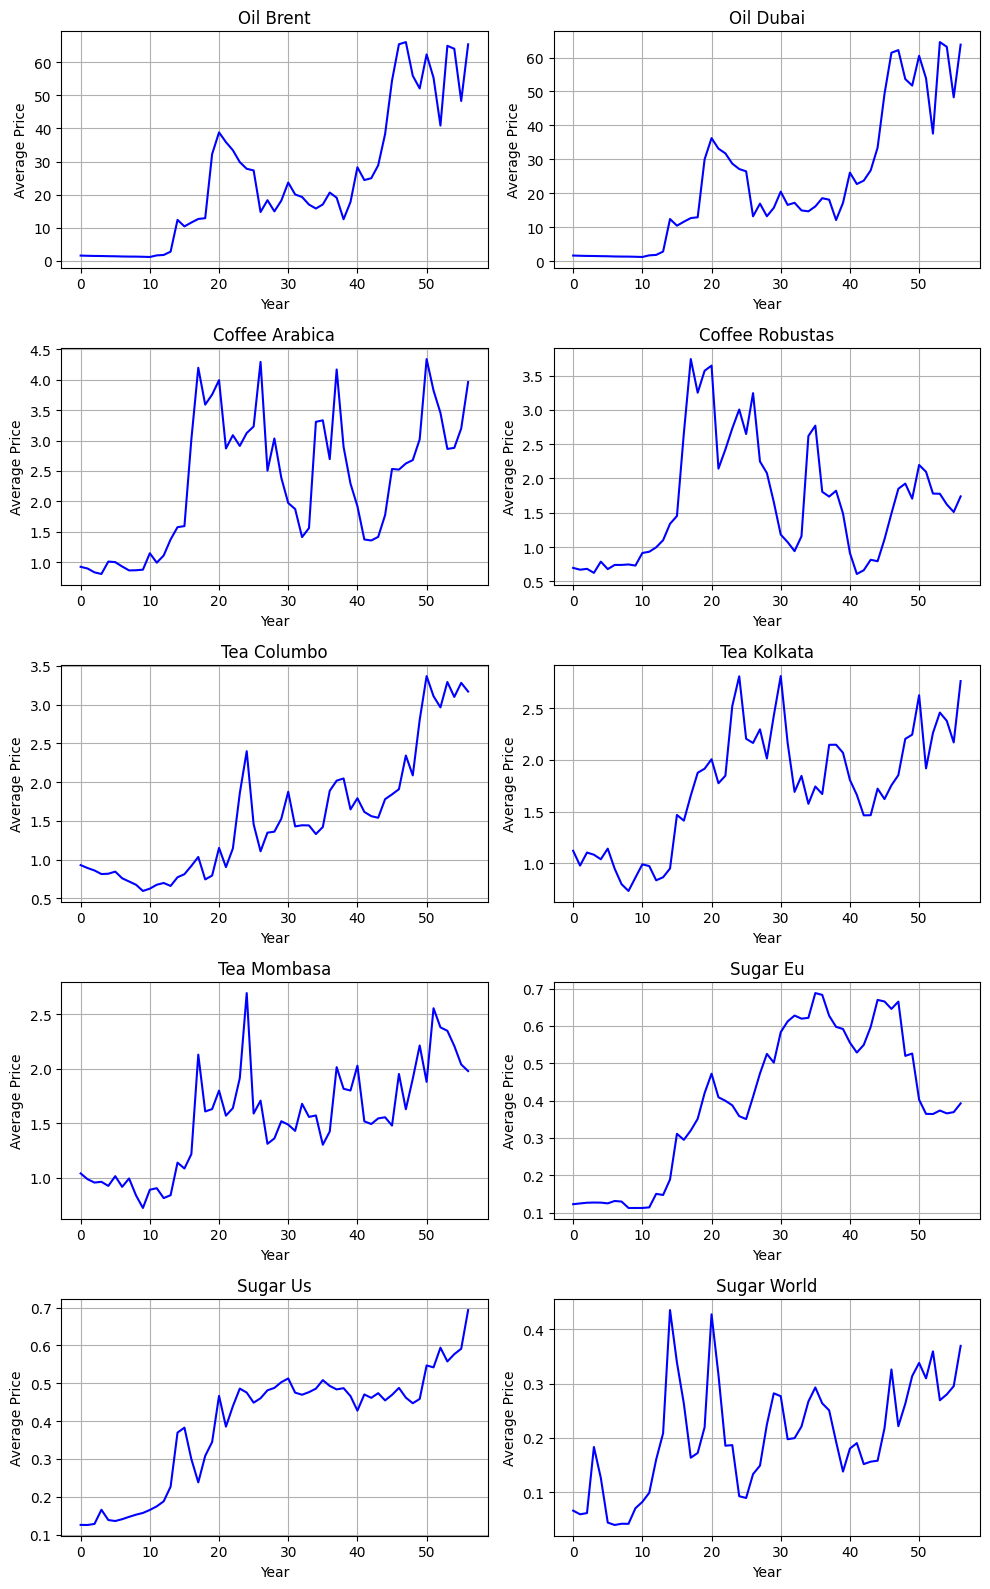

In [ ]:

import matplotlib.pyplot as plt

commodity_columns = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
                     'tea_columbo', 'tea_kolkata', 'tea_mombasa',
                     'sugar_eu', 'sugar_us', 'sugar_world']

plt.figure(figsize=(10, 16))
for i, col in enumerate(commodity_columns, 1):
    plt.subplot(5, 2, i)
    plt.plot(df_yearly.index, df_yearly[col], color='blue')
    plt.title(col.replace('_', ' ').title())
    plt.xlabel('Year')
    plt.ylabel('Average Price')
    plt.grid(True)

plt.tight_layout()
plt.show()


# Outliers

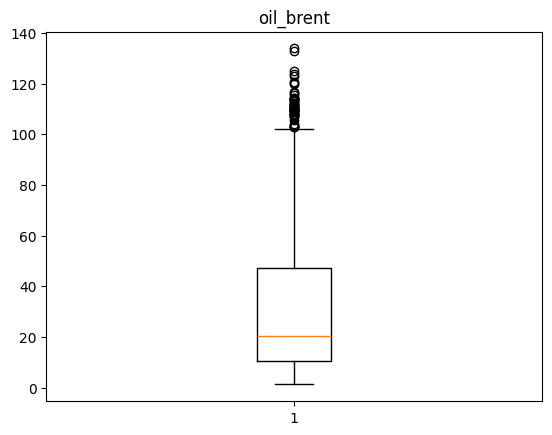

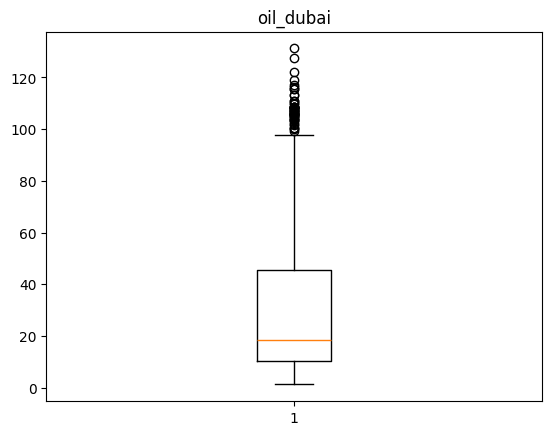

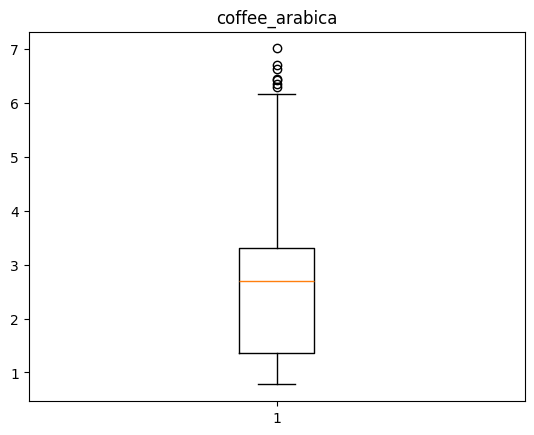

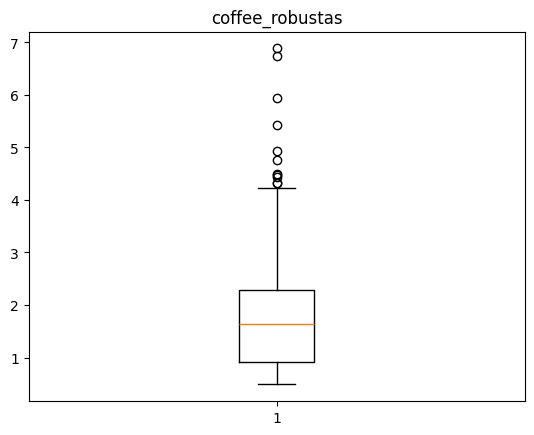

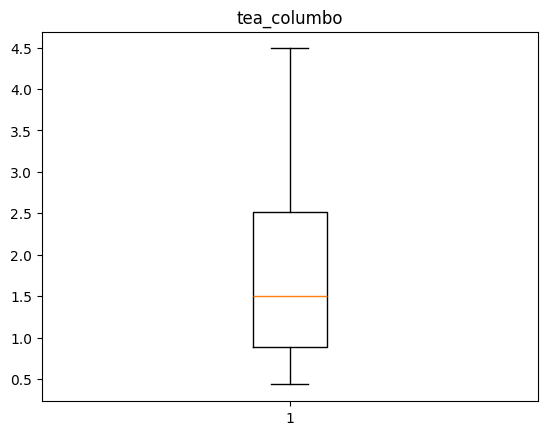

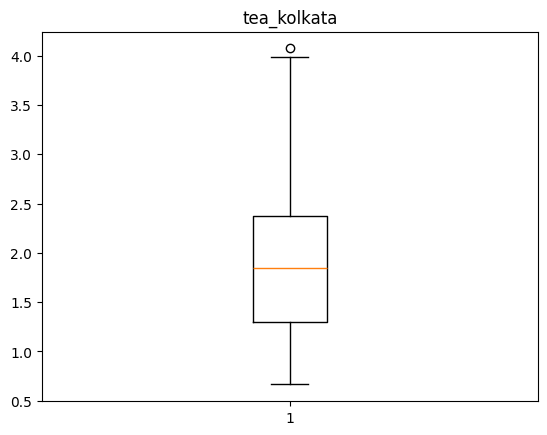

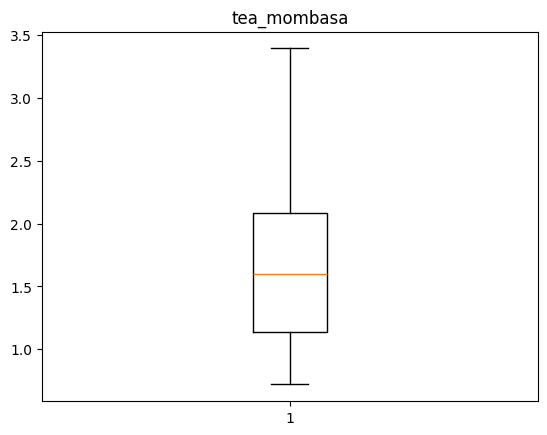

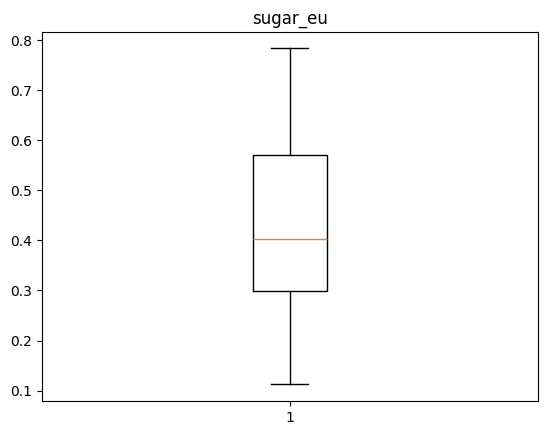

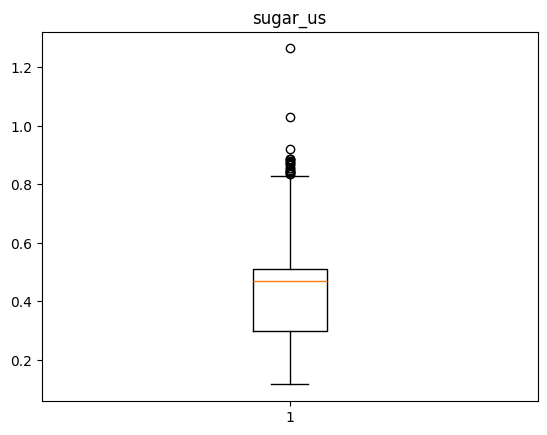

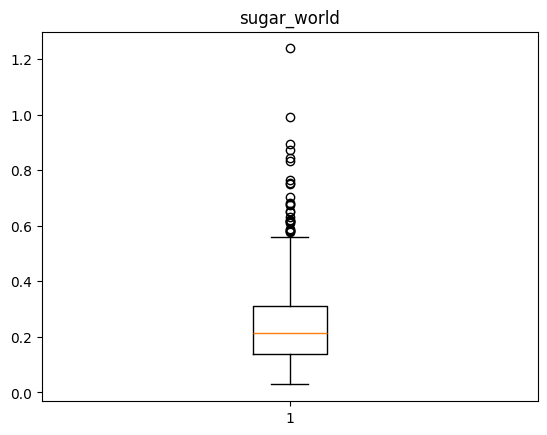

In [ ]:
for i in df.columns:
  if df[i].dtype == 'int64' or df[i].dtype == 'float64':
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
# remove the records which are outliers

for i in df.columns:
  if df[i].dtype == 'int64' or df[i].dtype == 'float64':
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    lower_fence = Q1 - 1.5 * IQR
    df = df[(df[i] >= lower_fence) & (df[i] <= upper_fence)]

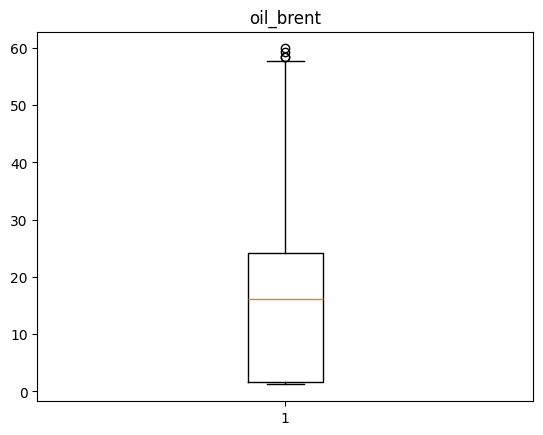

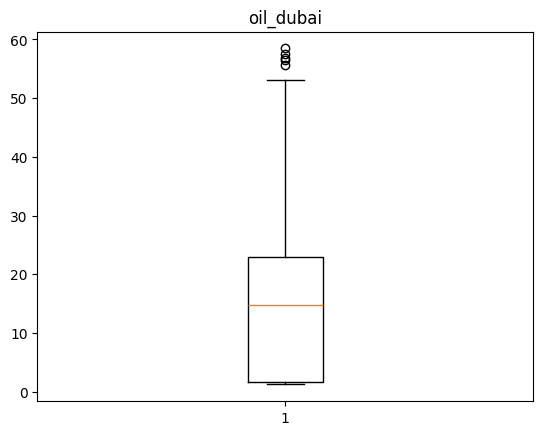

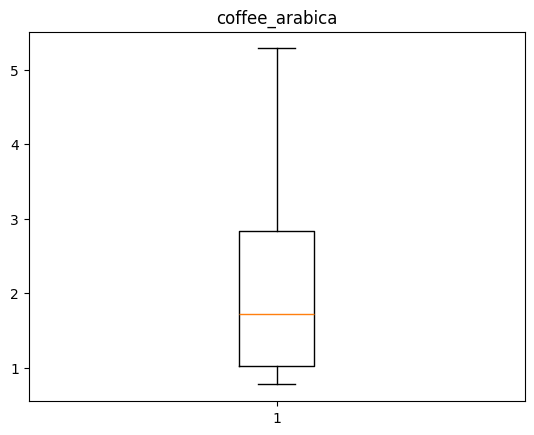

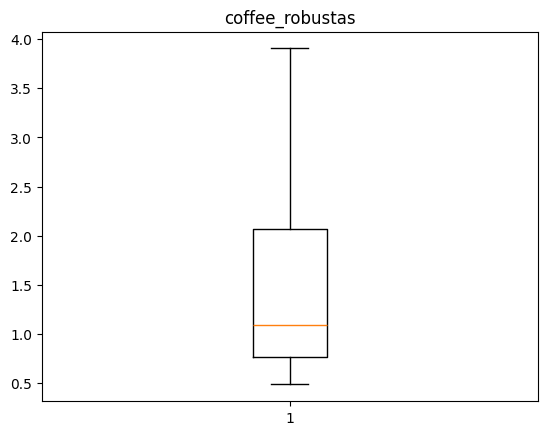

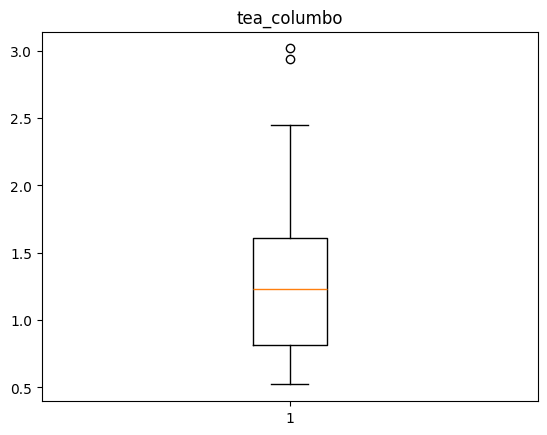

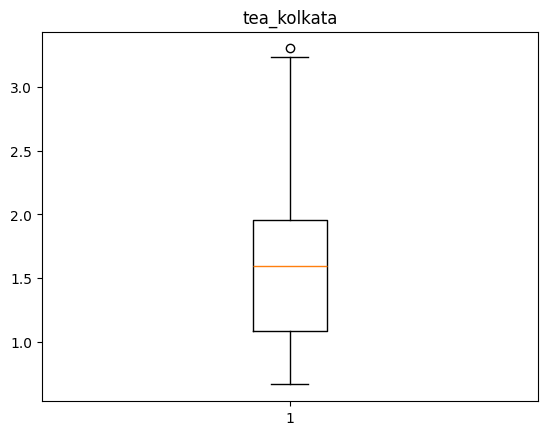

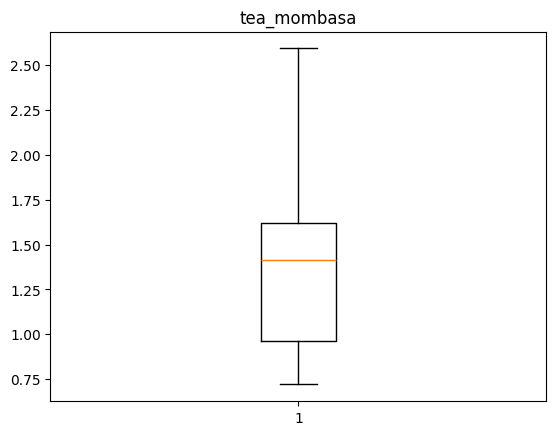

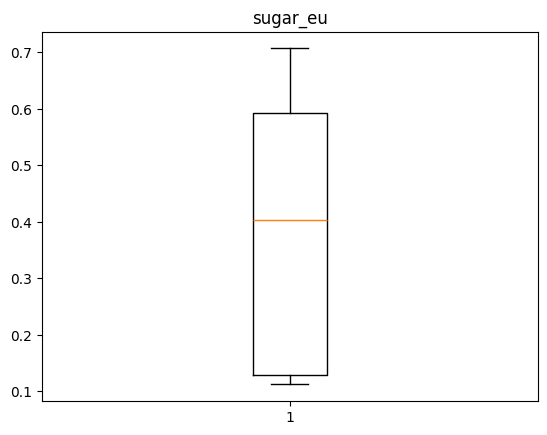

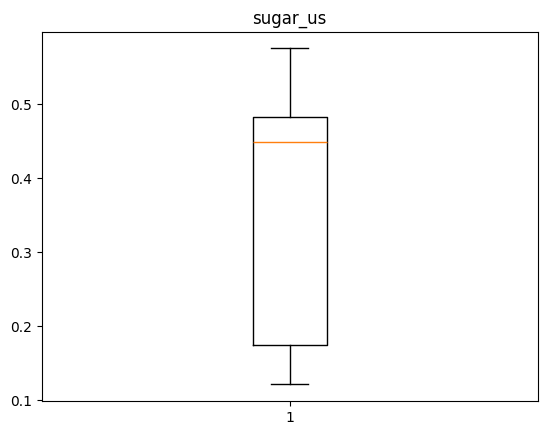

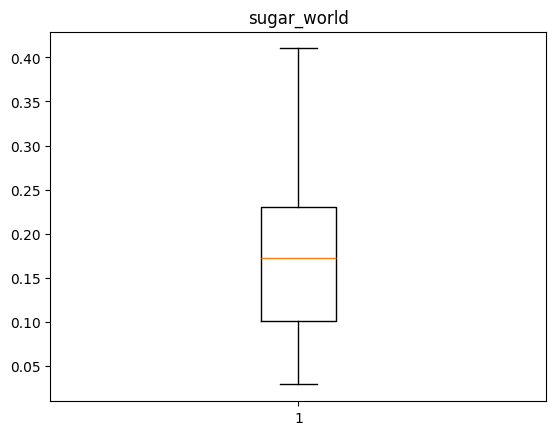

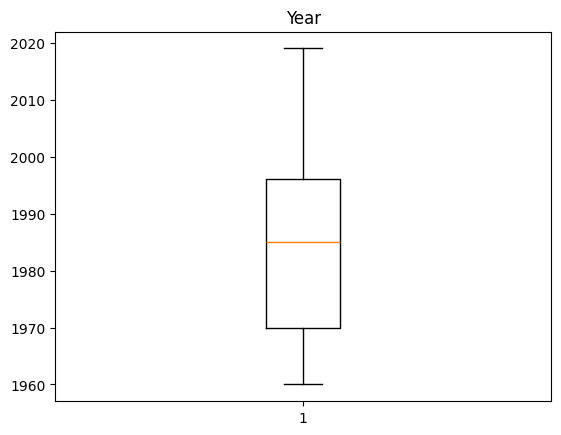

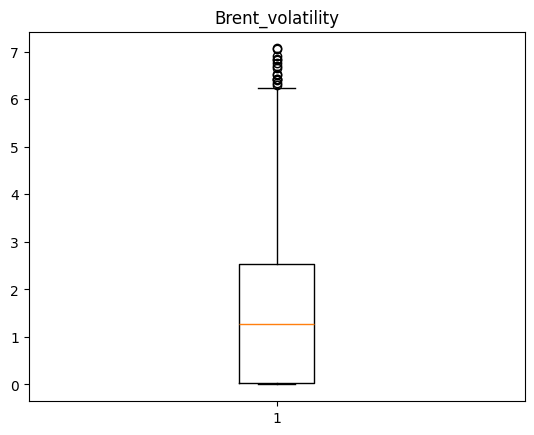

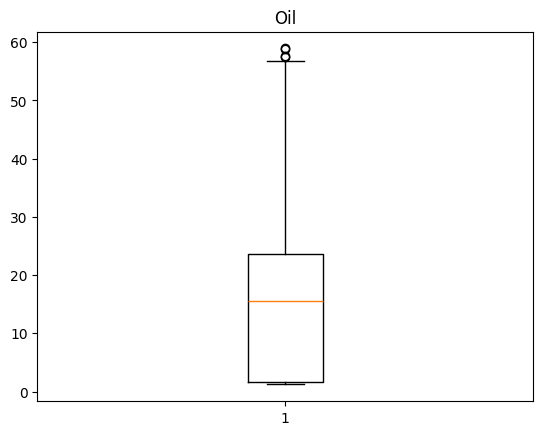

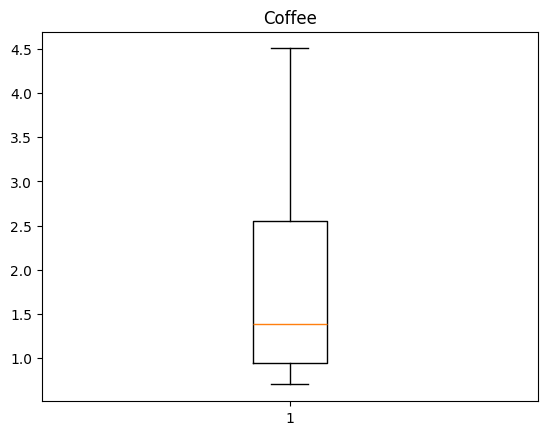

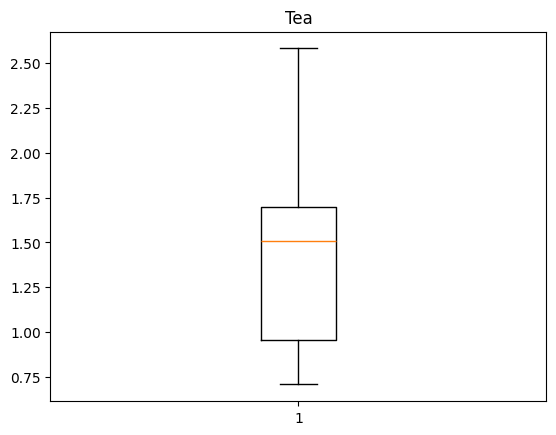

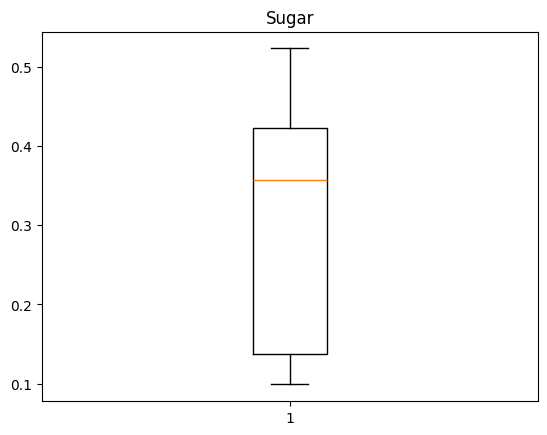

In [ ]:
for i in df.columns:
  if df[i].dtype == 'int64' or df[i].dtype == 'float64':
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
df_yearly = df_yearly.reset_index()
# as Group by function resets the index of date column, so again resetting the index

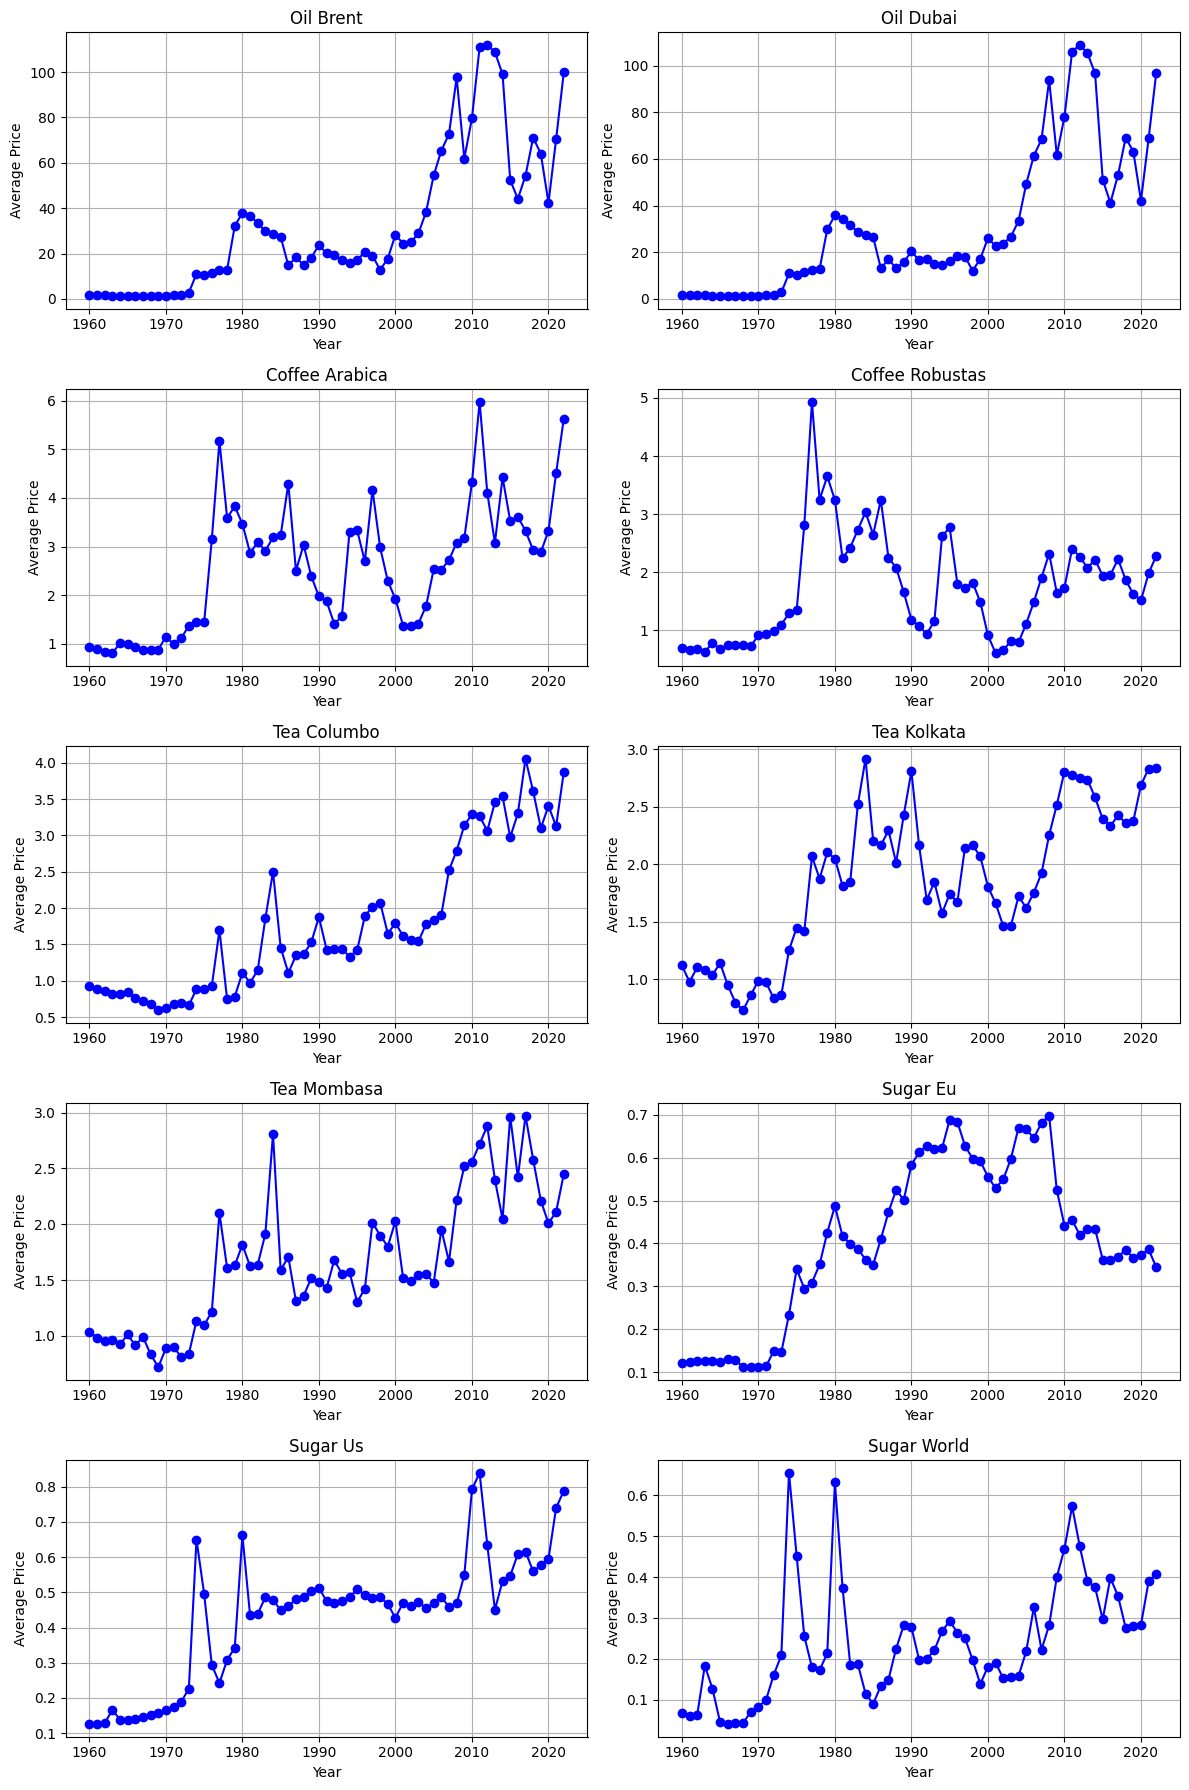

In [ ]:
import matplotlib.pyplot as plt

commodity_columns = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
                     'tea_columbo', 'tea_kolkata', 'tea_mombasa',
                     'sugar_eu', 'sugar_us', 'sugar_world']

# Plot all commodities in a 5x2 grid
plt.figure(figsize=(12, 18))
for i, col in enumerate(commodity_columns, 1):
    plt.subplot(5, 2, i)
    plt.plot(df_yearly['Year'], df_yearly[col], color='blue', marker='o')
    plt.title(col.replace('_', ' ').title())
    plt.xlabel('Year')
    plt.ylabel('Average Price')
    plt.grid(True)

plt.tight_layout()
plt.show()


# next EDA **Steps**
Check Correlation

*oil_brent and oil_dubai move together*

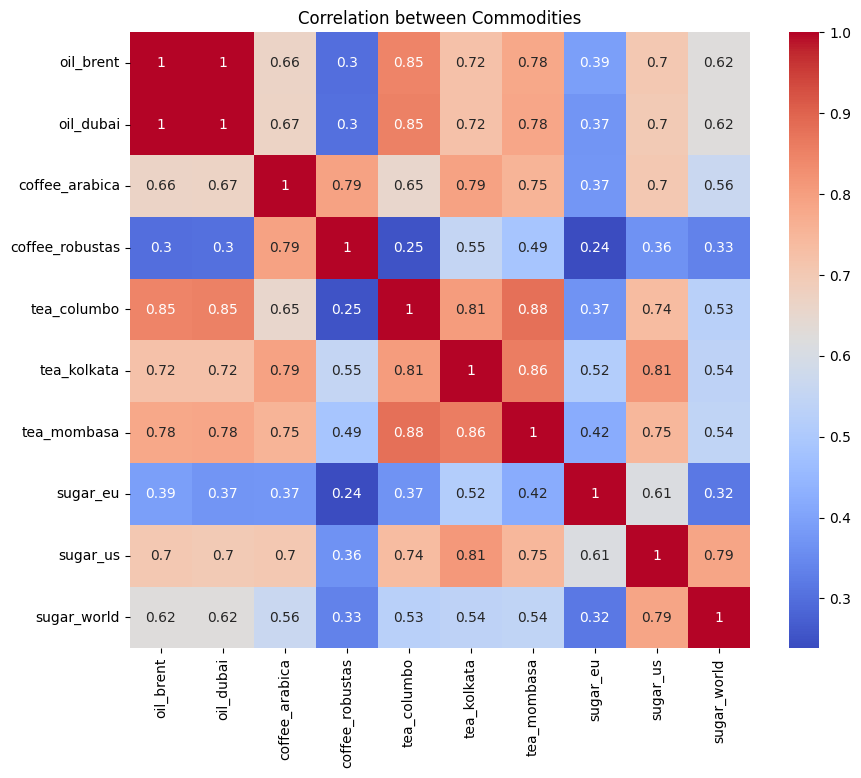

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df_yearly[commodity_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Commodities")
plt.show()


Insight: Oil prices usually correlate strongly with each other, coffee varieties may correlate *moderately*

*Summary statistics*

*   as we dont see much variations in prices, we dont need any Transformations like Std Scaler



In [ ]:
print(df_yearly[commodity_columns].describe())


        oil_brent   oil_dubai  coffee_arabica  coffee_robustas  tea_columbo  \
count   63.000000   63.000000       63.000000        63.000000    63.000000   
mean    32.724944   31.238130        2.576555         1.727478     1.777962   
std     31.555452   30.624359        1.294231         0.905826     0.995686   
min      1.210000    1.210000        0.805742         0.607175     0.596401   
25%     11.302500   11.302500        1.392683         0.922566     0.891194   
50%     20.650000   18.540000        2.723698         1.655617     1.529294   
75%     48.208750   45.729579        3.323419         2.257585     2.511234   
max    111.965558  108.904450        5.976137         4.932852     4.051667   

       tea_kolkata  tea_mombasa   sugar_eu   sugar_us  sugar_world  
count    63.000000    63.000000  63.000000  63.000000    63.000000  
mean      1.870308     1.671222   0.405158   0.432462     0.240263  
std       0.632031     0.604295   0.187218   0.181769     0.142093  
min       0.

In [ ]:
df_growth = df_yearly[commodity_columns].pct_change() * 100  # percent change
print(df_growth.head())


   oil_brent  oil_dubai  coffee_arabica  coffee_robustas  tea_columbo  \
0        NaN        NaN             NaN              NaN          NaN   
1  -3.680988  -3.680988       -3.029182        -3.809194    -4.063201   
2  -3.184713  -3.184713       -7.029265         1.907296    -3.529408   
3  -1.315789  -1.315789       -3.224870        -8.603974    -5.365860   
4  -3.333333  -3.333333       25.320357        26.232357     0.515463   

   tea_kolkata  tea_mombasa  sugar_eu   sugar_us  sugar_world  
0          NaN          NaN       NaN        NaN          NaN  
1   -12.734071    -5.128244  1.621622  -0.145985   -10.207678  
2    12.875523    -3.129447  1.595745   2.192982     3.756658  
3    -1.901139     0.734215  0.349040  29.184549   197.054850  
4    -4.069764    -3.935862 -0.144928 -16.389812   -31.057850  


1)What is the maximum and minimum price of Robusta coffee from 1960 to 2022 ?

2) Print the data between the 1960 to 1980

In [ ]:
df.columns

Index(['date', 'oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world', 'Month', 'Year'],
      dtype='object')

In [ ]:
max_price = df['coffee_robustas'].max()

In [ ]:
max_price

4.1621

In [ ]:
min_price = df['coffee_robustas'].min()

In [ ]:
min_price

0.4872098

In [ ]:
new_date = df[(df['date'] >= '1960-01-01') & (df['date'] <= '1980-12-01')]

In [ ]:
df

,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world,Month,Year
0,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600,1,1960
1,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900,2,1960
2,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300,3,1960
3,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100,4,1960
4,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300,5,1960
...,...,...,...,...,...,...,...,...,...,...,...,...,...
734,2021-03-01,65.19,63.95,3.682818,1.628332,3.270000,2.023144,1.996000,0.388704,0.671968,0.342598,3,2021
735,2021-04-01,64.77,62.37,3.718092,1.641560,3.210000,2.875405,1.915000,0.390500,0.689164,0.356267,4,2021
736,2021-05-01,68.04,65.98,4.110734,1.756641,3.080000,3.138924,1.916667,0.396705,0.712974,0.380517,5,2021
737,2021-06-01,73.07,70.96,4.243012,1.870179,2.930000,3.341515,1.824000,0.393505,0.728627,0.383824,6,2021


In [ ]:
new_date

,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world,Month,Year
0,1960-01-01,1.630000,1.63,0.9409,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.0666,1,1960
1,1960-02-01,1.630000,1.63,0.9469,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.0679,2,1960
2,1960-03-01,1.630000,1.63,0.9281,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.0683,3,1960
3,1960-04-01,1.630000,1.63,0.9303,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.0681,4,1960
4,1960-05-01,1.630000,1.63,0.9200,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.0683,5,1960
...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,1979-11-01,42.000000,39.50,4.5574,3.909000,0.922358,2.198167,1.631778,0.476859,0.359133,0.3030,11,1979
239,1979-12-01,40.500000,39.00,4.2831,3.902000,1.313053,2.044681,1.655072,0.487882,0.403445,0.3290,12,1979
240,1980-01-01,40.000000,38.00,3.8078,3.571300,1.185947,2.030021,1.842562,0.492733,0.433428,0.3810,1,1980
242,1980-03-01,38.250000,35.75,4.1173,3.722500,1.141416,1.985558,1.785539,0.463411,0.466939,0.4330,3,1980


Histogram (Univariate)
Shows the distribution of each commodity:

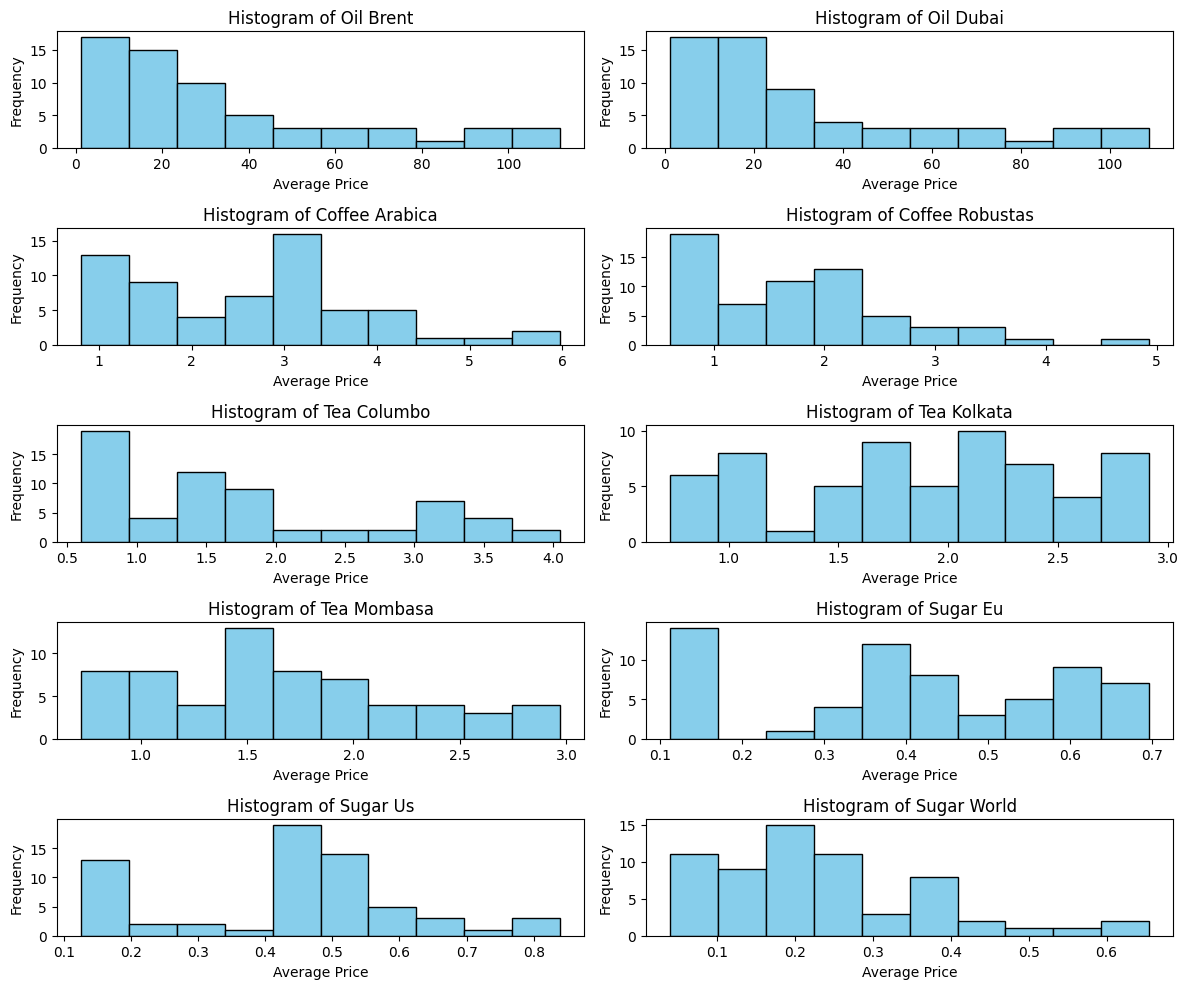

In [ ]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(commodity_columns, 1):
    plt.subplot(5, 2, i)
    plt.hist(df_yearly[col], bins=10, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col.replace("_", " ").title()}')
    plt.xlabel("Average Price")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


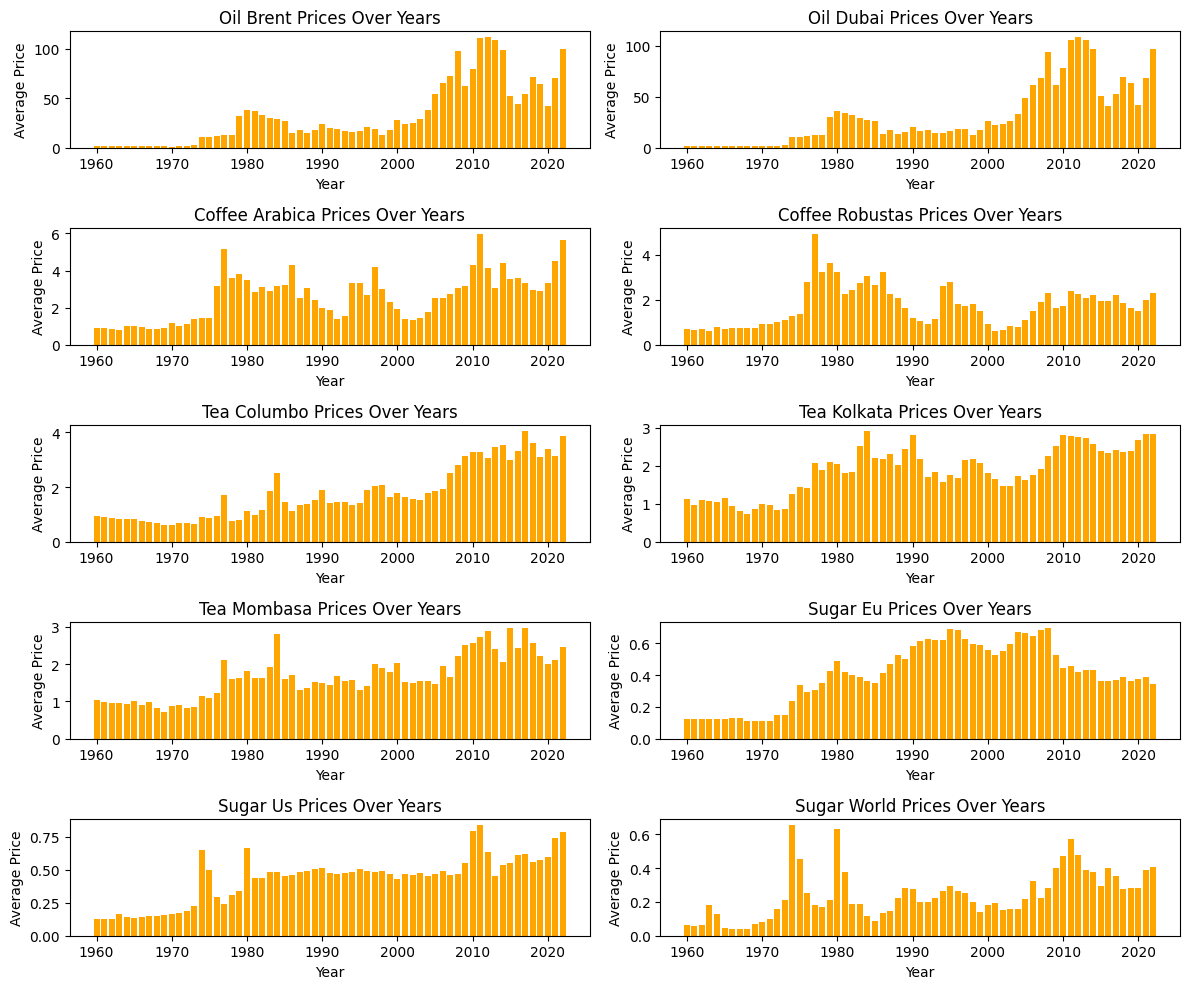

In [ ]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(commodity_columns, 1):
    plt.subplot(5, 2, i)
    plt.bar(df_yearly['Year'], df_yearly[col], color='orange')
    plt.title(f'{col.replace("_", " ").title()} Prices Over Years')
    plt.xlabel("Year")
    plt.ylabel("Average Price")
plt.tight_layout()
plt.show()


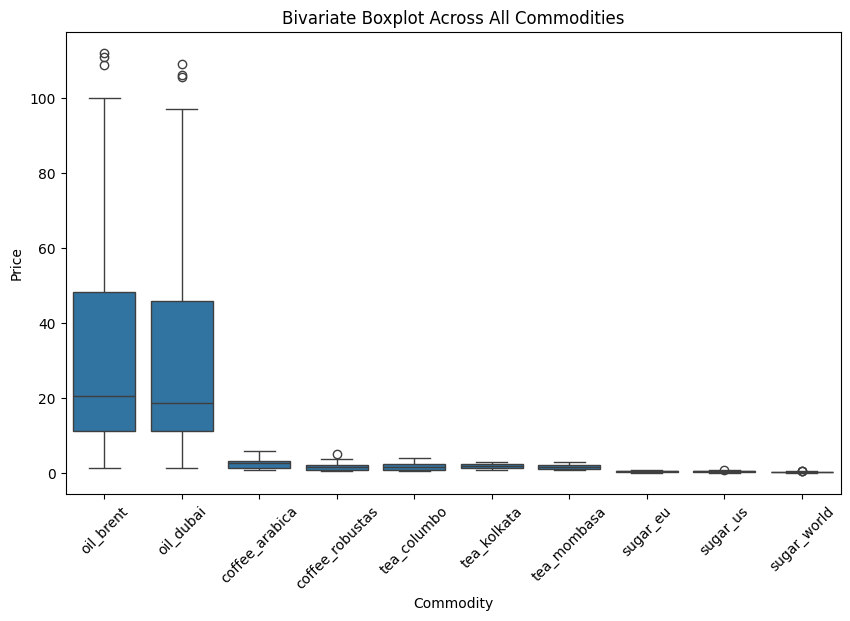

In [ ]:
# Create categories
df_bivar = df_yearly[['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
                      'tea_columbo', 'tea_kolkata', 'tea_mombasa',
                      'sugar_eu', 'sugar_us', 'sugar_world']]

df_melted = pd.melt(df_bivar, var_name='Commodity', value_name='Price')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Commodity', y='Price', data=df_melted)
plt.title("Bivariate Boxplot Across All Commodities")
plt.xticks(rotation=45)
plt.show()


# Pie Chart

Which commodity has the highest average price over the years?” (Pie Chart)

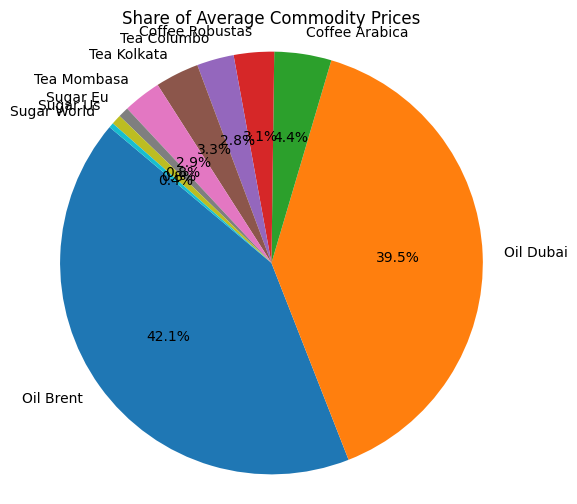

In [ ]:
import matplotlib.pyplot as plt

# Select commodity columns
commodities = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
               'tea_columbo', 'tea_kolkata', 'tea_mombasa',
               'sugar_eu', 'sugar_us', 'sugar_world']

# Calculate average price per commodity
avg_prices = df[commodities].mean()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(avg_prices, labels=[c.replace('_',' ').title() for c in commodities],
        autopct='%1.1f%%', startangle=140)
plt.title('Share of Average Commodity Prices')
plt.axis('equal')
plt.show()


**Which category — Oil, Coffee, Tea, Sugar — contributes most?**

*   here, oil makes up the largest portion of average prices.”






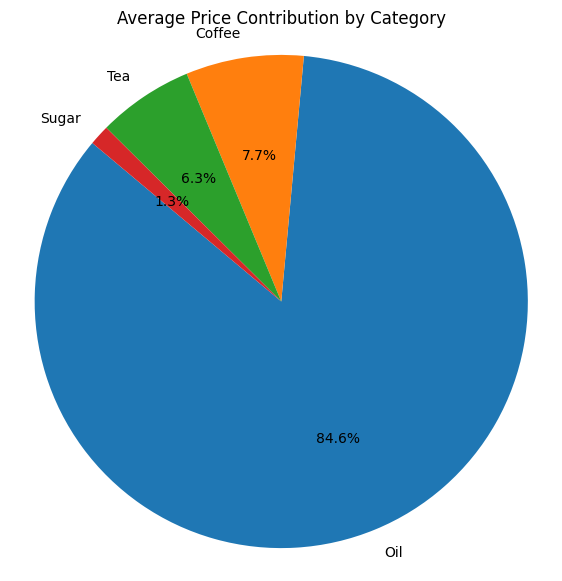

In [ ]:
category_avg = {
    'Oil': df[['oil_brent','oil_dubai']].mean().mean(),
    'Coffee': df[['coffee_arabica','coffee_robustas']].mean().mean(),
    'Tea': df[['tea_columbo','tea_kolkata','tea_mombasa']].mean().mean(),
    'Sugar': df[['sugar_eu','sugar_us','sugar_world']].mean().mean()
}

plt.figure(figsize=(7,7))
plt.pie(category_avg.values(), labels=category_avg.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Average Price Contribution by Category')
plt.axis('equal')
plt.show()


*Animated Donut Chart: Commodity Price Share Over Time**

In [ ]:
# Animated Donut (Pie with hole) by Year using plotly.graph_objects
import pandas as pd
import plotly.graph_objects as go

# --- Prepare the data: group commodity columns into 4 categories and average by Year ---
# (Adjust names if your df uses different column names)
commodities_oil   = ['oil_brent', 'oil_dubai']
commodities_coffee= ['coffee_arabica', 'coffee_robustas']
commodities_tea   = ['tea_columbo', 'tea_kolkata', 'tea_mombasa']
commodities_sugar = ['sugar_eu', 'sugar_us', 'sugar_world']

# Ensure Year is numeric/int
df['Year'] = df['Year'].astype(int)

# Compute category-wise mean per row first (if prices are per-row), then aggregate by Year
df['Oil']    = df[commodities_oil].mean(axis=1)
df['Coffee'] = df[commodities_coffee].mean(axis=1)
df['Tea']    = df[commodities_tea].mean(axis=1)
df['Sugar']  = df[commodities_sugar].mean(axis=1)

df_cat_yearly = df.groupby('Year')[['Oil','Coffee','Tea','Sugar']].mean().reset_index()

# Drop any years with all-NaN if present
df_cat_yearly = df_cat_yearly.dropna(how='all', subset=['Oil','Coffee','Tea','Sugar'])

years = df_cat_yearly['Year'].astype(str).tolist()
categories = ['Oil','Coffee','Tea','Sugar']

# --- Build initial trace (first year) ---
initial_vals = df_cat_yearly.loc[0, categories].values

fig = go.Figure(
    data=[go.Pie(labels=categories,
                 values=initial_vals,
                 hole=0.45,
                 sort=False,
                 textinfo='percent+label',
                 hoverinfo='label+value+percent'
                )]
)

# --- Create frames: one frame per year ---
frames = []
for i, yr in enumerate(years):
    vals = df_cat_yearly.loc[i, categories].values
    frame = go.Frame(
        data=[go.Pie(labels=categories, values=vals, hole=0.45, sort=False,
                     textinfo='percent+label', hoverinfo='label+value+percent')],
        name=yr
    )
    frames.append(frame)

fig.frames = frames

# --- Add animation controls (play/pause) and a slider ---
fig.update_layout(
    title_text='Animated Donut: Commodity Category Share Over Years',
    annotations=[dict(text='Category share', x=0.5, y=0.5, font_size=14, showarrow=False)],
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=1.05,
        x=1.15,
        xanchor='right',
        yanchor='top',
        buttons=[
            dict(label='Play',
                 method='animate',
                 args=[None, {"frame": {"duration": 800, "redraw": True},
                              "fromcurrent": True, "transition": {"duration": 300, "easing":"linear"}}]),
            dict(label='Pause',
                 method='animate',
                 args=[[None], {"frame": {"duration": 0, "redraw": False},
                                "mode":"immediate",
                                "transition": {"duration": 0}}])
        ]
    )],
    sliders=[{
        "pad": {"b": 10, "t": 50},
        "len": 0.9,
        "x": 0.05,
        "y": 0,
        "steps": [
            {"args": [[yr], {"frame": {"duration": 300, "redraw": True},
                             "mode": "immediate",
                             "transition": {"duration": 200}}],
             "label": yr, "method": "animate"} for yr in years
        ]
    }]
)

# Show figure (in notebook this will be interactive)
fig.show()


**Plot the trend of sugar_world prices over time.**

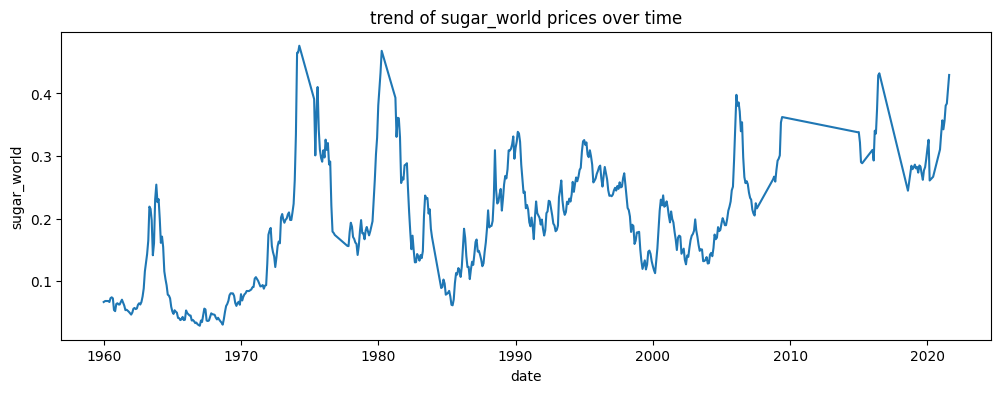

In [ ]:
plt.figure(figsize = (12,4))
sns.lineplot(x = 'date', y = 'sugar_world', data = df)
plt.title('trend of sugar_world prices over time')
plt.show()

# **Category-level Trends**

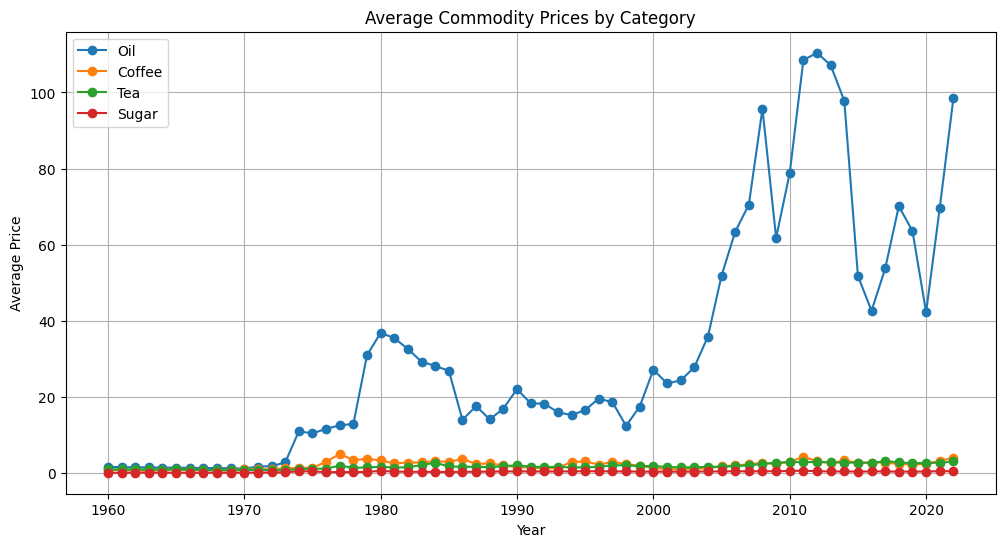

In [ ]:
df_yearly['Oil'] = df_yearly[['oil_brent','oil_dubai']].mean(axis=1)
df_yearly['Coffee'] = df_yearly[['coffee_arabica','coffee_robustas']].mean(axis=1)
df_yearly['Tea'] = df_yearly[['tea_columbo','tea_kolkata','tea_mombasa']].mean(axis=1)
df_yearly['Sugar'] = df_yearly[['sugar_eu','sugar_us','sugar_world']].mean(axis=1)

plt.figure(figsize=(12,6))
for cat in ['Oil','Coffee','Tea','Sugar']:
    plt.plot(df_yearly['Year'], df_yearly[cat], marker='o', label=cat)
plt.title("Average Commodity Prices by Category")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.legend()
plt.grid(True)
plt.show()


**Which commodity has the highest average price over the full dataset?**

In [ ]:
avg_prices = df[['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world']].mean()

In [ ]:
df.columns

Index(['date', 'oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world', 'Month', 'Year'],
      dtype='object')

In [ ]:
avg_prices.sort_values(ascending = False)

,0
oil_brent,20.999878
oil_dubai,19.715082
coffee_arabica,2.178528
tea_kolkata,1.671906
coffee_robustas,1.538308
tea_mombasa,1.452477
tea_columbo,1.414661
sugar_eu,0.399039
sugar_us,0.376091
sugar_world,0.187043


As we can see from above, oil_brent is highest

In [ ]:
df.mean()

,0
date,1986-11-28 03:07:30
oil_brent,20.999878
oil_dubai,19.715082
coffee_arabica,2.178528
coffee_robustas,1.538308
tea_columbo,1.414661
tea_kolkata,1.671906
tea_mombasa,1.452477
sugar_eu,0.399039
sugar_us,0.376091


As we can see oil_brent and oil_dubai have higher price, so Plot Percentage

*   This lets us compare their rate of increase or volatility fairly, regardless of their absolute price difference.

```
# This is formatted as code
```



change Comparison b/w them

In [ ]:
# Yearly percentage change for Brent and Dubai oil
df_yearly['Brent_pct_change'] = df_yearly['oil_brent'].pct_change() * 100
df_yearly['Dubai_pct_change'] = df_yearly['oil_dubai'].pct_change() * 100

# Check the first few rows
print(df_yearly[['Year', 'Brent_pct_change', 'Dubai_pct_change']])


    Year  Brent_pct_change  Dubai_pct_change
0   1960               NaN               NaN
1   1961         -3.680988         -3.680988
2   1962         -3.184713         -3.184713
3   1963         -1.315789         -1.315789
4   1964         -3.333333         -3.333333
..   ...               ...               ...
58  2018         30.664460         30.190307
59  2019         -9.905494         -8.639223
60  2020        -33.938936        -33.259467
61  2021         66.532703         63.180363
62  2022         41.708465         41.049585

[63 rows x 3 columns]


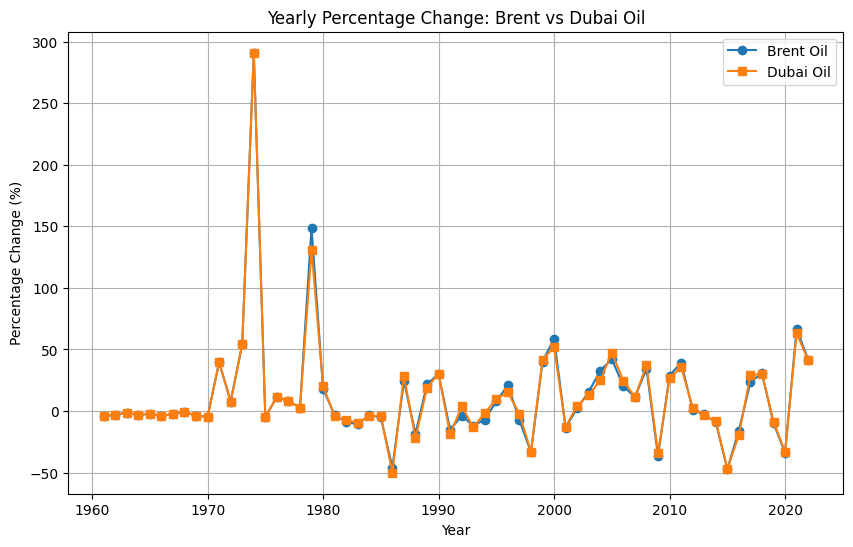

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df_yearly['Year'], df_yearly['Brent_pct_change'], marker='o', label='Brent Oil')
plt.plot(df_yearly['Year'], df_yearly['Dubai_pct_change'], marker='s', label='Dubai Oil')
plt.title("Yearly Percentage Change: Brent vs Dubai Oil")
plt.xlabel("Year")
plt.ylabel("Percentage Change (%)")
plt.legend()
plt.grid(True)
plt.show()


How much each oil price changed year over year.

Which one is more volatile. almost both similar.

# Price Ratio

*   How much more expensive is Brent compared to Dubai at each point in time




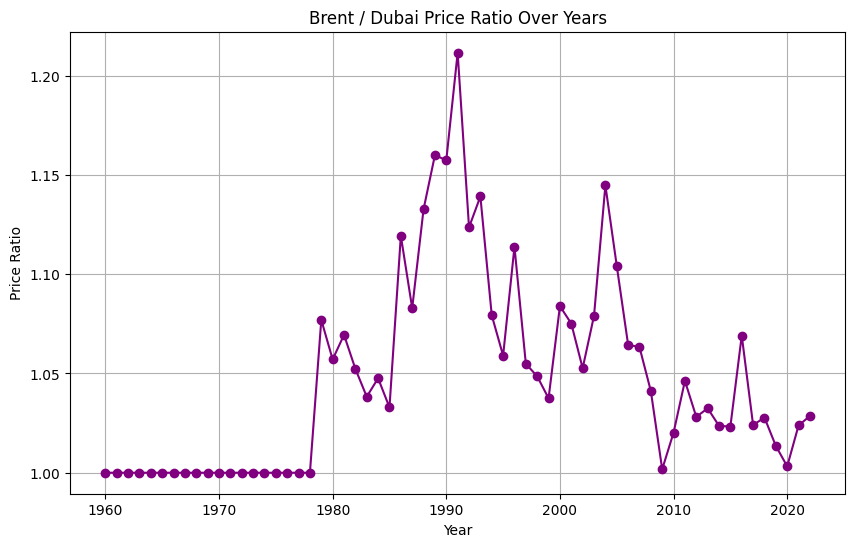

In [ ]:
df_yearly['Brent_to_Dubai_ratio'] = df_yearly['oil_brent'] / df_yearly['oil_dubai']

plt.figure(figsize=(10,6))
plt.plot(df_yearly['Year'], df_yearly['Brent_to_Dubai_ratio'], marker='o', color='purple')
plt.title("Brent / Dubai Price Ratio Over Years")
plt.xlabel("Year")
plt.ylabel("Price Ratio")
plt.grid(True)
plt.show()


Brent trades at a premium or discount to Dubai oil over time.

-----++------++-------+------+++++---------+++==+++++++------------------

**# Boxplot of sugar prices by region (eu, us, world).**

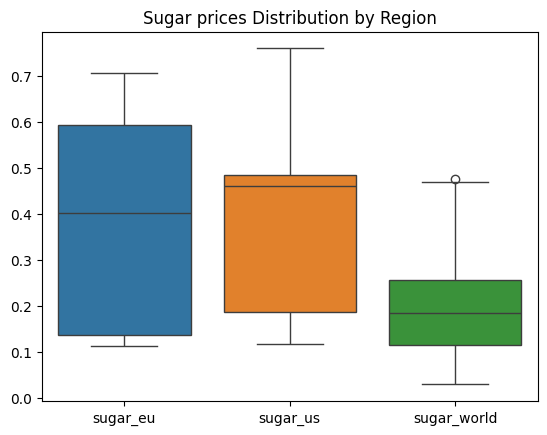

In [ ]:
sns.boxplot(data = df[['sugar_eu', 'sugar_us', 'sugar_world']])
plt.title("Sugar prices Distribution by Region")
plt.show()

**Compare price trends of Arabica vs Robusta coffee?**

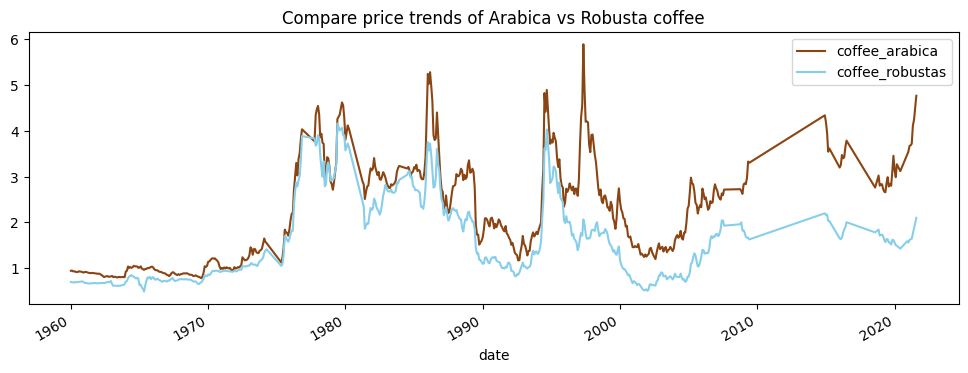

In [ ]:
df[['date','coffee_arabica','coffee_robustas']].set_index('date').plot(figsize = (12,4), color = ['saddlebrown','skyblue'])
plt.title('Compare price trends of Arabica vs Robusta coffee')
plt.show()

# --------------------------

In [ ]:
import pandas as pd

# Combine Year and Month into a datetime
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').set_index('Date')

df.head()


,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world,Month,Year
Date,,,,,,,,,,,,,
1960-01-01,1960-01-01,1.63,1.63,0.9409,0.696864,0.930301,1.121401,1.0374,0.122356,0.116845,0.0666,1,1960
1960-02-01,1960-02-01,1.63,1.63,0.9469,0.688707,0.930301,1.121401,1.0374,0.122356,0.119049,0.0679,2,1960
1960-03-01,1960-03-01,1.63,1.63,0.9281,0.688707,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683,3,1960
1960-04-01,1960-04-01,1.63,1.63,0.9303,0.684519,0.930301,1.121401,1.0374,0.122356,0.123459,0.0681,4,1960
1960-05-01,1960-05-01,1.63,1.63,0.9200,0.690692,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683,5,1960


Now df is ready for time series analysis

# 1) Plot Historical Time Series

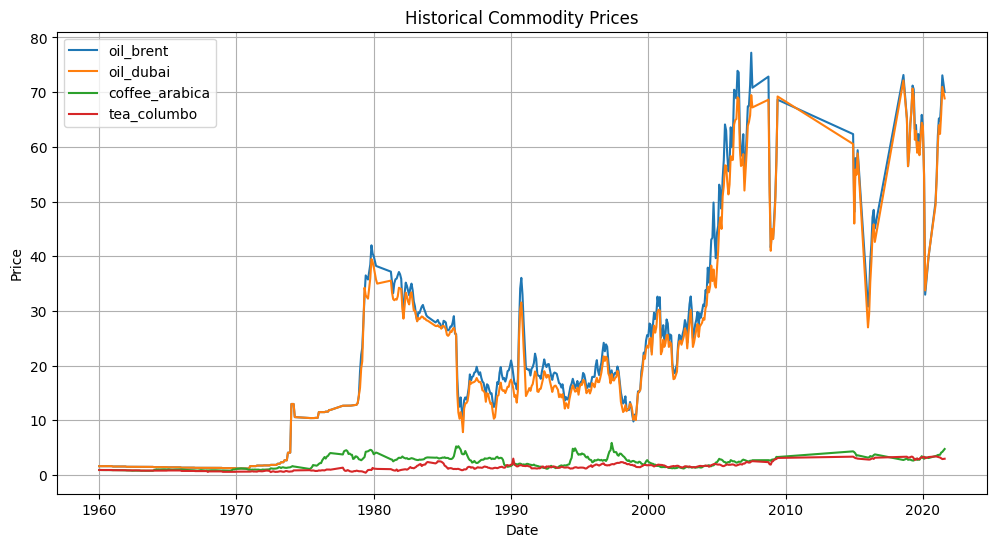

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for col in ['oil_brent','oil_dubai','coffee_arabica','tea_columbo']:
    plt.plot(df.index, df[col], label=col)

plt.title("Historical Commodity Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


# 2) Check for Stationarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}:")
    print(f"  Test Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical Values: {result[4]}")
    if result[1] < 0.05:
        print("  -> Series is Stationary")
    else:
        print("  -> Series is Non-Stationary")
    print("-"*50)

for col in ['oil_brent','oil_dubai','coffee_arabica','tea_columbo']:
    adf_test(df[col], col)


ADF Test for oil_brent:
  Test Statistic: 0.0131
  p-value: 0.9596
  Critical Values: {'1%': np.float64(-3.4421660928041633), '5%': np.float64(-2.8667523104859627), '10%': np.float64(-2.56954599309042)}
  -> Series is Non-Stationary
--------------------------------------------------
ADF Test for oil_dubai:
  Test Statistic: 0.3198
  p-value: 0.9782
  Critical Values: {'1%': np.float64(-3.4421660928041633), '5%': np.float64(-2.8667523104859627), '10%': np.float64(-2.56954599309042)}
  -> Series is Non-Stationary
--------------------------------------------------
ADF Test for coffee_arabica:
  Test Statistic: -2.2777
  p-value: 0.1792
  Critical Values: {'1%': np.float64(-3.441874550188182), '5%': np.float64(-2.8666239496633246), '10%': np.float64(-2.569477593105571)}
  -> Series is Non-Stationary
--------------------------------------------------
ADF Test for tea_columbo:
  Test Statistic: -0.7110
  p-value: 0.8439
  Critical Values: {'1%': np.float64(-3.4420185006698127), '5%': np.floa

Insight: Non-stationary series → need differencing before ARIMA

# 3) Seasonal Decomposition

1. Use statsmodels to split trend, seasonality, and residuals



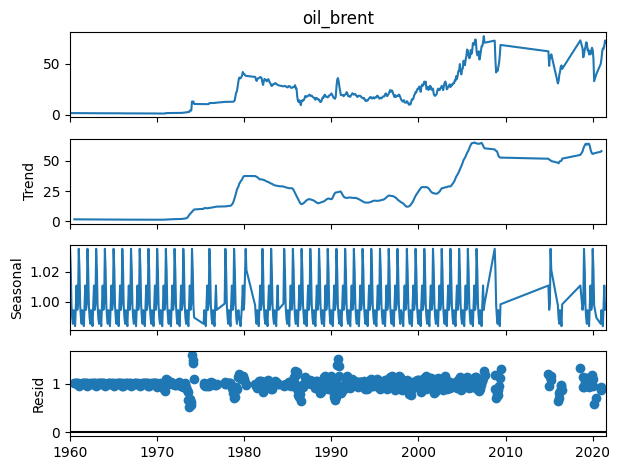

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['oil_brent'], model='multiplicative', period=12)
result.plot()
plt.show()


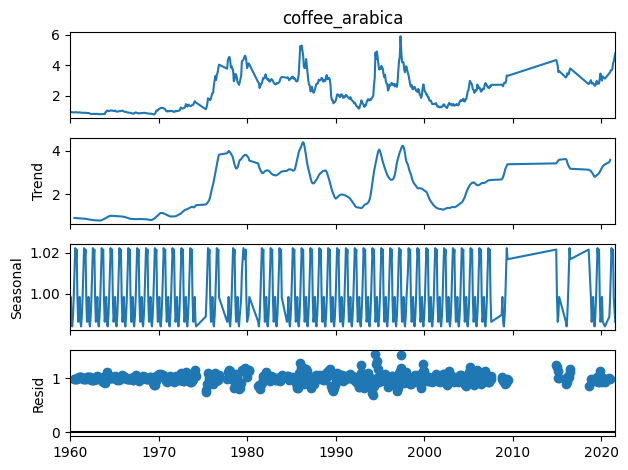

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['coffee_arabica'], model='multiplicative', period=12)
result.plot()
plt.show()


# 4) check Rolling Statistics

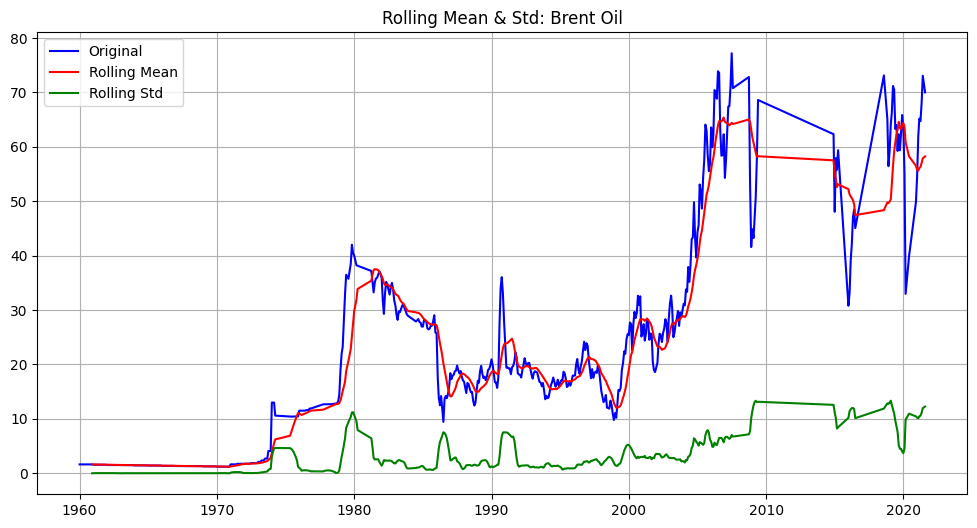

In [ ]:
window = 12  # 12-month rolling
plt.figure(figsize=(12,6))
plt.plot(df['oil_brent'], label='Original', color='blue')
plt.plot(df['oil_brent'].rolling(window).mean(), label='Rolling Mean', color='red')
plt.plot(df['oil_brent'].rolling(window).std(), label='Rolling Std', color='green')
plt.title("Rolling Mean & Std: Brent Oil")
plt.legend()
plt.grid(True)
plt.show()


# 5) Autocorrelation Analysis

1.  Autocorrelation / lag analysis: check if past prices predict future prices (good for forecasting later)



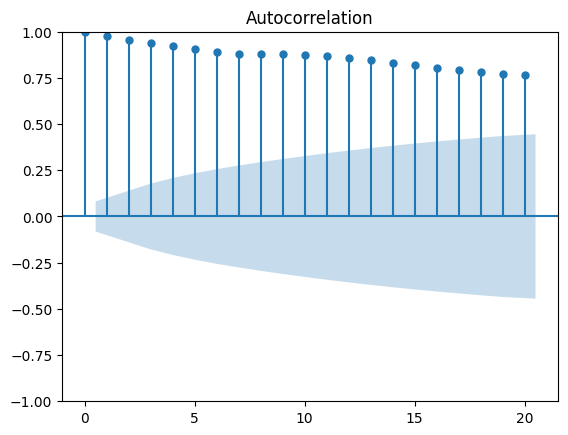

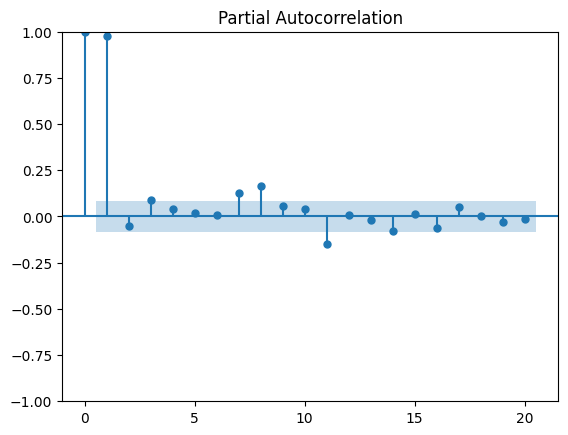

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['oil_brent'].dropna(), lags=20)
plt.show()

plot_pacf(df['oil_brent'].dropna(), lags=20)
plt.show()


**Plot Monthly Seasonality for a Commodity**

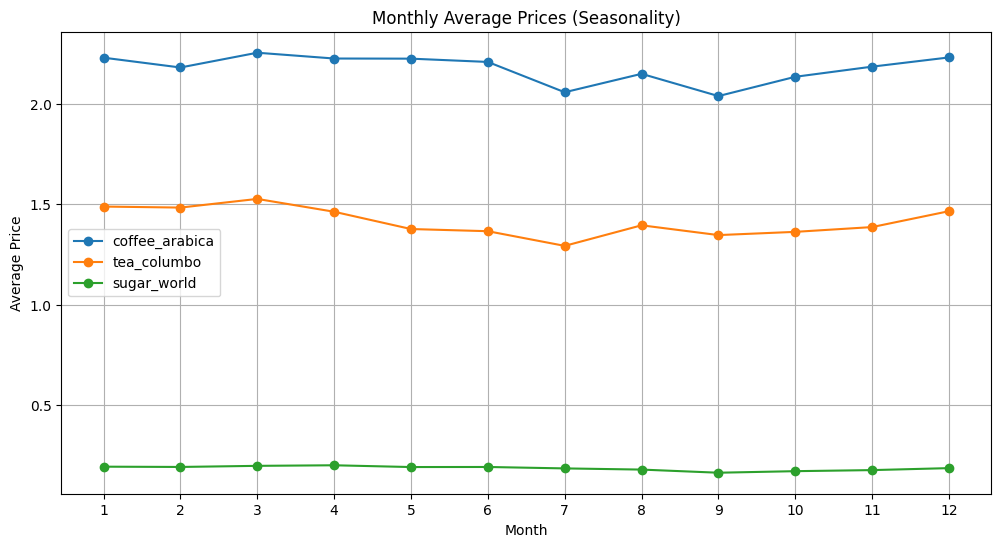

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for col in ['coffee_arabica','tea_columbo','sugar_world']:
    monthly_avg = df[col].groupby(df.index.month).mean()  # average per month
    plt.plot(range(1,13), monthly_avg, marker='o', label=col)

plt.title("Monthly Average Prices (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(range(1,13))
plt.legend()
plt.grid(True)
plt.show()


Peaks/troughs may indicate harvest season, demand cycles, or trading patterns

**Yearly Trends (Time Series Line Plot)**

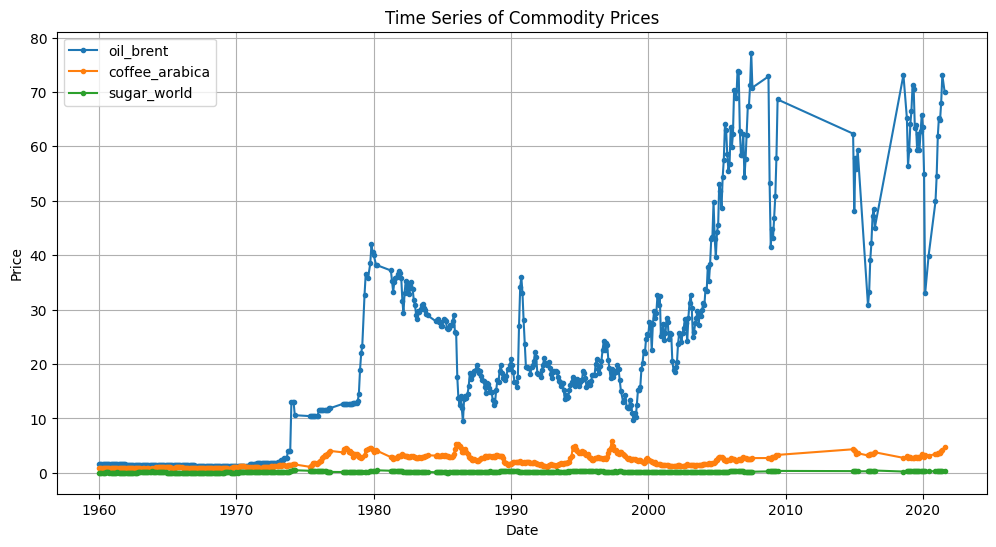

In [ ]:
plt.figure(figsize=(12,6))
for col in ['oil_brent','coffee_arabica','sugar_world']:
    plt.plot(df.index, df[col], marker='.', label=col)

plt.title("Time Series of Commodity Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


mooth out short-term fluctuations to highlight trends

**Compare Multiple Commodities by Month (Seasonality Heatmap)**

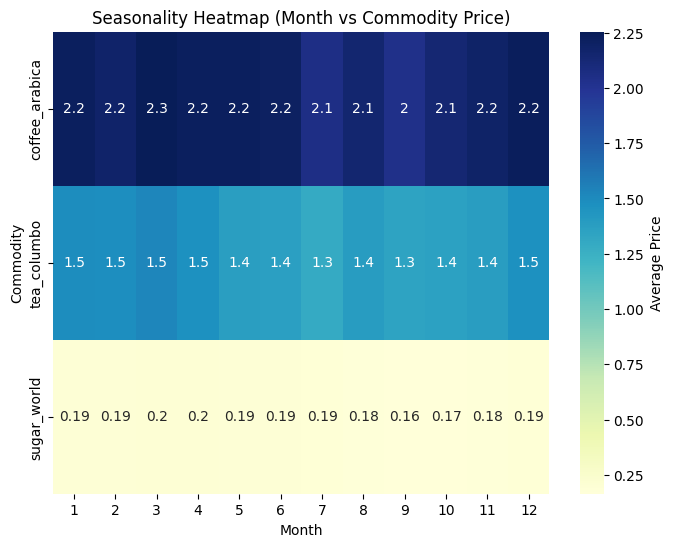

In [ ]:
monthly_avg = df.groupby(df.index.month)[['coffee_arabica','tea_columbo','sugar_world']].mean()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(monthly_avg.T, annot=True, cmap='YlGnBu', cbar_kws={'label':'Average Price'})
plt.title("Seasonality Heatmap (Month vs Commodity Price)")
plt.xlabel("Month")
plt.ylabel("Commodity")
plt.show()


**Volatility and Risk Analysis**

1.  rolling standard deviation (volatility) for each commodity
2.  Identify which commodities are most unpredictable, like an analyst assessing risk



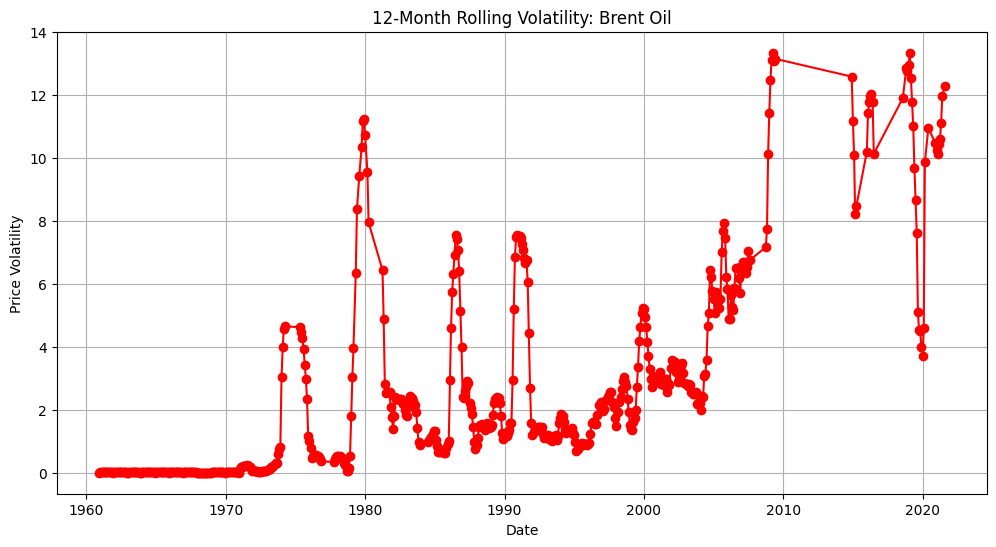

In [ ]:
# 12-month rolling standard deviation (volatility)
df['Brent_volatility'] = df['oil_brent'].rolling(window=12).std()

# Plot
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Brent_volatility'], marker='o', color='red')
plt.title("12-Month Rolling Volatility: Brent Oil")
plt.xlabel("Date")
plt.ylabel("Price Volatility")
plt.grid(True)
plt.show()


**Comparative Analysis Across Categories**

1.  This shows relative growth visually



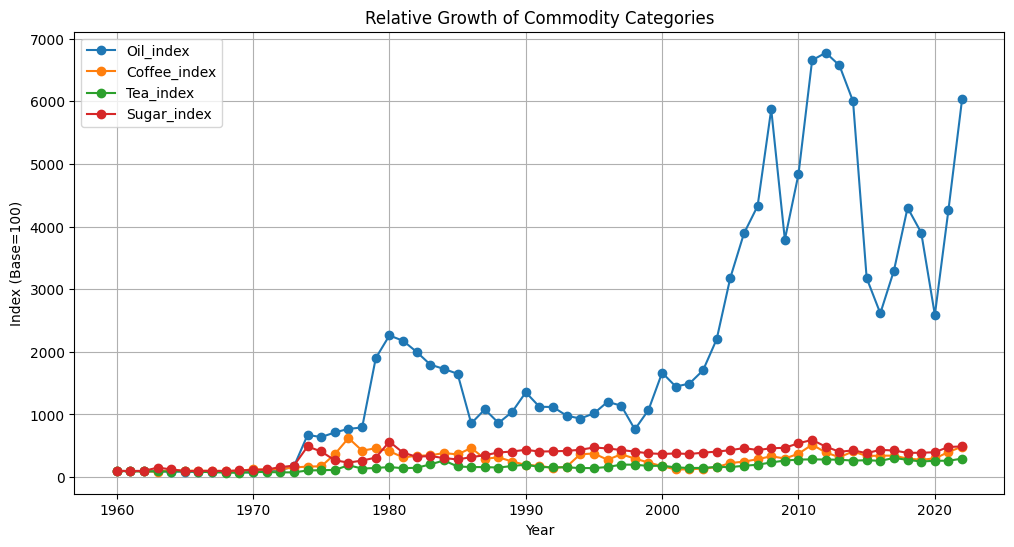

In [ ]:
# Normalize categories to 100 for comparison
df_yearly['Oil_index'] = df_yearly[['oil_brent','oil_dubai']].mean(axis=1) / df_yearly[['oil_brent','oil_dubai']].mean(axis=1).iloc[0] * 100
df_yearly['Coffee_index'] = df_yearly[['coffee_arabica','coffee_robustas']].mean(axis=1) / df_yearly[['coffee_arabica','coffee_robustas']].mean(axis=1).iloc[0] * 100
df_yearly['Tea_index'] = df_yearly[['tea_columbo','tea_kolkata','tea_mombasa']].mean(axis=1) / df_yearly[['tea_columbo','tea_kolkata','tea_mombasa']].mean(axis=1).iloc[0] * 100
df_yearly['Sugar_index'] = df_yearly[['sugar_eu','sugar_us','sugar_world']].mean(axis=1) / df_yearly[['sugar_eu','sugar_us','sugar_world']].mean(axis=1).iloc[0] * 100

# Plot
plt.figure(figsize=(12,6))
for col in ['Oil_index','Coffee_index','Tea_index','Sugar_index']:
    plt.plot(df_yearly['Year'], df_yearly[col], marker='o', label=col)
plt.title("Relative Growth of Commodity Categories")
plt.xlabel("Year")
plt.ylabel("Index (Base=100)")
plt.legend()
plt.grid(True)
plt.show()
